In [1]:
# ============================================================
#Import libraries
# ============================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gradio as gr
from pyspark.sql import SparkSession
from google.colab import drive
import cv2


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
#Fix PySpark Java Gateway Error
# ============================================================

# 1. Install Java and PySpark
!apt-get install openjdk-11-jdk -qq > /dev/null
!pip install -q pyspark==3.5.1

# 2. Set JAVA_HOME
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] += ":/usr/lib/jvm/java-11-openjdk-amd64/bin"

# 3. Import and create SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("PneumoNet_Preprocessing").getOrCreate()
print(" Spark session created successfully")


 Spark session created successfully


In [4]:
# ============================================================
# Spark session for inspection
# ============================================================
spark = SparkSession.builder.appName("PneumoNet_Preprocessing").getOrCreate()

dataset_path = "/content/drive/MyDrive/chest_xray"

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

train_df = spark.read.format("binaryFile").load(f"{train_dir}/*")
val_df = spark.read.format("binaryFile").load(f"{val_dir}/*")
test_df = spark.read.format("binaryFile").load(f"{test_dir}/*")

print("Dataset sizes (Spark inspection):")
print("Train:", train_df.count(), " Validation:", val_df.count(), " Test:", test_df.count())


Dataset sizes (Spark inspection):
Train: 5216  Validation: 16  Test: 624


In [6]:
# ============================================================
# Data augmentation & loaders
# ============================================================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)

print("Classes:", train_data.classes)


Classes: ['NORMAL', 'PNEUMONIA']


In [14]:
# ============================================================
# ResNet50 Transfer Learning Setup
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Freeze all layers initially
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the final classification layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
print(" Model ready for fine-tuning")


 Model ready for fine-tuning


In [15]:
# ===========================================================
# Training setup
# ============================================================
# Handle class imbalance
class_counts = np.bincount(train_data.targets)
class_weights = torch.tensor([1.0 / c for c in class_counts], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 12
train_losses, val_losses = [], []
best_val_acc = 0.0


In [17]:
# ============================================================
# Training + Fine-Tuning (with Train Accuracy Added)
# ============================================================

train_losses, val_losses = [], []
train_accuracies = []
val_accuracies = []
best_val_acc = 0.0

for epoch in range(num_epochs):
    # -------------------------------
    # Training Phase
    # -------------------------------
    model.train()
    running_loss = 0.0
    y_train_true, y_train_pred = [], []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Track predictions for train accuracy
        _, preds = torch.max(outputs, 1)
        y_train_true.extend(labels.cpu().numpy())
        y_train_pred.extend(preds.cpu().numpy())

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_acc = accuracy_score(y_train_true, y_train_pred)
    train_accuracies.append(train_acc)

    # -------------------------------
    #  Validation Phase
    # -------------------------------
    model.eval()
    val_loss = 0.0
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = accuracy_score(y_true, y_pred)
    val_accuracies.append(val_acc)

    # -------------------------------
    # Save Best Model
    # -------------------------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/pneumonet_resnet50_best.pth")

    # -------------------------------
    # Epoch Summary
    # -------------------------------
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    scheduler.step()

# ============================================================
# Unfreeze all layers for Fine-Tuning
# ============================================================
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)
print(" Unfrozen all layers for fine-tuning...")


Epoch [1/12] Train Loss: 0.4970 | Train Acc: 82.40% | Val Loss: 0.3899 | Val Acc: 87.50%
Epoch [2/12] Train Loss: 0.3443 | Train Acc: 89.17% | Val Loss: 0.3117 | Val Acc: 87.50%
Epoch [3/12] Train Loss: 0.2838 | Train Acc: 91.05% | Val Loss: 0.2773 | Val Acc: 93.75%
Epoch [4/12] Train Loss: 0.2728 | Train Acc: 90.38% | Val Loss: 0.2839 | Val Acc: 93.75%
Epoch [5/12] Train Loss: 0.2717 | Train Acc: 90.45% | Val Loss: 0.2913 | Val Acc: 93.75%
Epoch [6/12] Train Loss: 0.2677 | Train Acc: 90.59% | Val Loss: 0.2728 | Val Acc: 93.75%
Epoch [7/12] Train Loss: 0.2629 | Train Acc: 90.43% | Val Loss: 0.2670 | Val Acc: 93.75%
Epoch [8/12] Train Loss: 0.2630 | Train Acc: 90.76% | Val Loss: 0.2598 | Val Acc: 93.75%
Epoch [9/12] Train Loss: 0.2654 | Train Acc: 90.59% | Val Loss: 0.2639 | Val Acc: 93.75%
Epoch [10/12] Train Loss: 0.2642 | Train Acc: 90.74% | Val Loss: 0.2579 | Val Acc: 93.75%
Epoch [11/12] Train Loss: 0.2638 | Train Acc: 90.62% | Val Loss: 0.2749 | Val Acc: 93.75%
Epoch [12/12] Train

In [18]:
# ============================================================
# 🧠 Fine-Tune All Layers (with Train & Val Metrics)
# ============================================================

fine_tune_epochs = 5
best_val_acc = 0.0

for epoch in range(fine_tune_epochs):
    # -------------------------------
    # Training Phase
    # -------------------------------
    model.train()
    running_loss = 0.0
    y_train_true, y_train_pred = [], []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        y_train_true.extend(labels.cpu().numpy())
        y_train_pred.extend(preds.cpu().numpy())

    avg_train_loss = running_loss / len(train_loader)
    train_acc = accuracy_score(y_train_true, y_train_pred)

    # -------------------------------
    # Validation Phase
    # -------------------------------
    model.eval()
    val_loss = 0.0
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(y_true, y_pred)

    # -------------------------------
    # Save Best Model (Optional)
    # -------------------------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/pneumonet_resnet50_best_finetuned.pth")

    # -------------------------------
    # Epoch Summary
    # -------------------------------
    print(f"[Fine-Tune Epoch {epoch+1}/{fine_tune_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

# ============================================================
# 💾 Save Final Fine-Tuned Model
# ============================================================
torch.save(model.state_dict(), "/content/drive/MyDrive/pneumonet_resnet50_finetuned.pth")
print("Final fine-tuned model saved to Drive.")


[Fine-Tune Epoch 1/5] Train Loss: 0.1563 | Train Acc: 94.27% | Val Loss: 0.2294 | Val Acc: 93.75%
[Fine-Tune Epoch 2/5] Train Loss: 0.1040 | Train Acc: 95.97% | Val Loss: 0.2314 | Val Acc: 87.50%
[Fine-Tune Epoch 3/5] Train Loss: 0.0890 | Train Acc: 96.89% | Val Loss: 0.0759 | Val Acc: 100.00%
[Fine-Tune Epoch 4/5] Train Loss: 0.0735 | Train Acc: 97.32% | Val Loss: 0.0759 | Val Acc: 100.00%
[Fine-Tune Epoch 5/5] Train Loss: 0.0688 | Train Acc: 97.60% | Val Loss: 0.0568 | Val Acc: 100.00%
Final fine-tuned model saved to Drive.


In [7]:
from torchvision import models
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Must match the model setup during training
model = models.resnet50(weights='IMAGENET1K_V1')
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Load the same file you actually saved
checkpoint_path = "/content/drive/MyDrive/pneumonet_resnet50_finetuned.pth"
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()
print("Loaded fine-tuned model successfully.")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


Loaded fine-tuned model successfully.


Accuracy:  0.9311
Precision: 0.9201
Recall:    0.9744
F1 Score:  0.9465
ROC-AUC:   0.9776


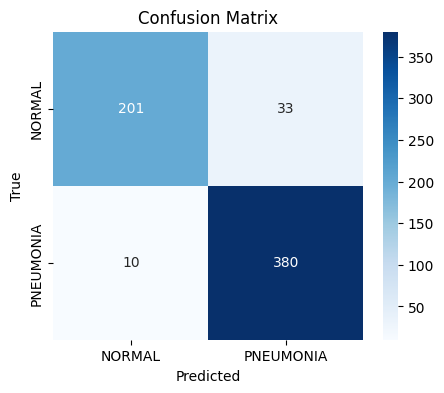

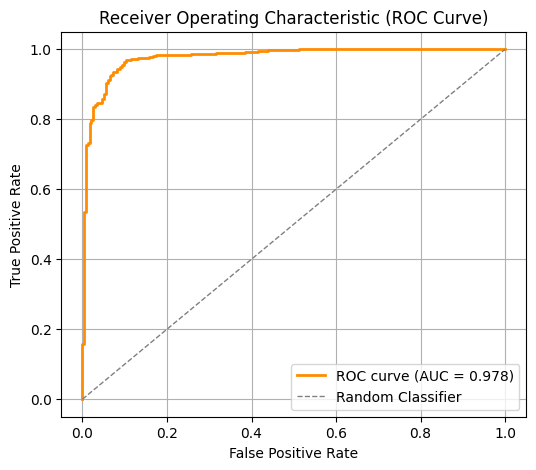

In [8]:
# ============================================================
# 🧪 Evaluate model on test set + ROC-AUC Curve
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred, y_probs = [], [], []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of pneumonia
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

# ====== Metrics ======
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_probs)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# ====== Confusion Matrix ======
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_data.classes, yticklabels=train_data.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ====== ROC-AUC Curve ======
fpr, tpr, _ = roc_curve(y_true, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC Curve)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


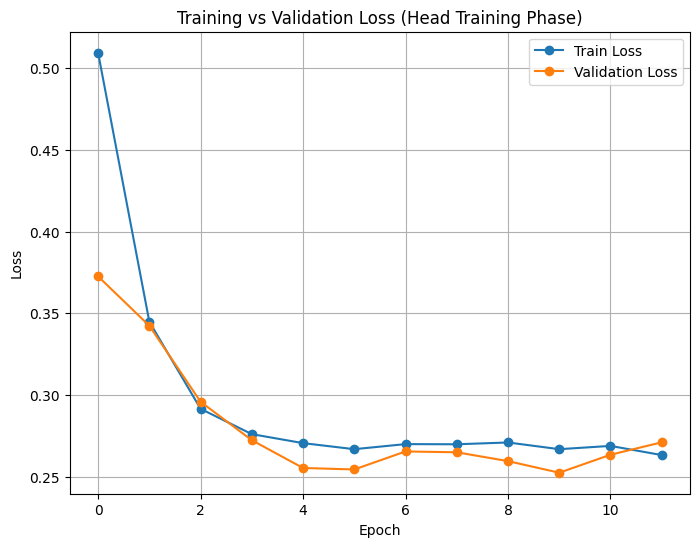

In [9]:
# ============================================================
# Plot: Train Loss vs. Validation Loss (Frozen Layers Phase)
# ============================================================
import matplotlib.pyplot as plt

# Values from your first code
train_losses = [0.5094, 0.3449, 0.2916, 0.2761, 0.2706, 0.2669, 0.2700, 0.2699, 0.2710, 0.2669, 0.2689, 0.2633]
val_losses =   [0.3726, 0.3424, 0.2959, 0.2724, 0.2554, 0.2545, 0.2655, 0.2650, 0.2596, 0.2525, 0.2635, 0.2711]

plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.title("Training vs Validation Loss (Head Training Phase)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()




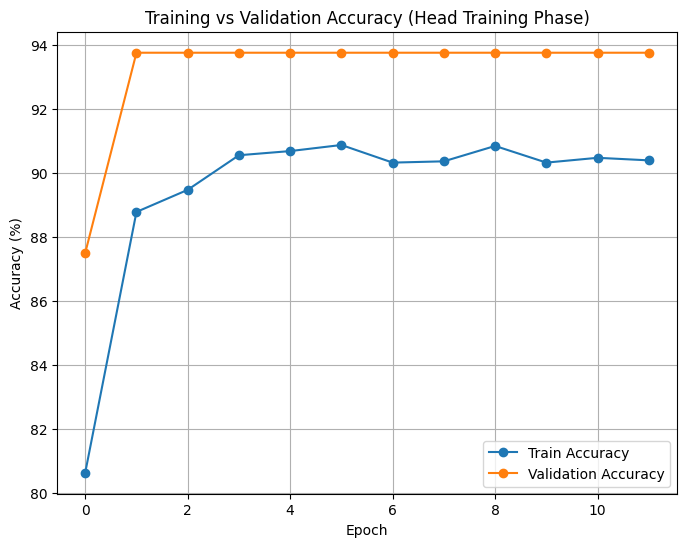

In [10]:
# ============================================================
# Plot: Train Accuracy vs. Validation Accuracy (Frozen Layers Phase)
# ============================================================
import matplotlib.pyplot as plt

train_accuracies = [80.64, 88.78, 89.47, 90.55, 90.68, 90.87, 90.32, 90.36, 90.84, 90.32, 90.47, 90.39]
val_accuracies =   [87.50, 93.75, 93.75, 93.75, 93.75, 93.75, 93.75, 93.75, 93.75, 93.75, 93.75, 93.75]

plt.figure(figsize=(8,6))
plt.plot(train_accuracies, label="Train Accuracy", marker='o')
plt.plot(val_accuracies, label="Validation Accuracy", marker='o')
plt.title("Training vs Validation Accuracy (Head Training Phase)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()




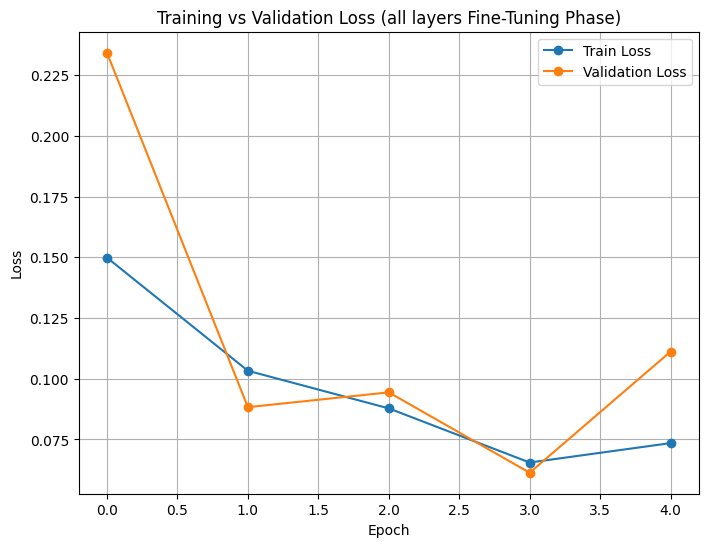

In [11]:
# ============================================================
# Plot: Train Loss vs. Validation Loss (Fine-Tuning Phase)
# ============================================================
import matplotlib.pyplot as plt

train_losses_ft = [0.1499, 0.1033, 0.0878, 0.0655, 0.0735]
val_losses_ft =   [0.2343, 0.0883, 0.0944, 0.0613, 0.1112]

plt.figure(figsize=(8,6))
plt.plot(train_losses_ft, label="Train Loss", marker='o')
plt.plot(val_losses_ft, label="Validation Loss", marker='o')
plt.title("Training vs Validation Loss (all layers Fine-Tuning Phase)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



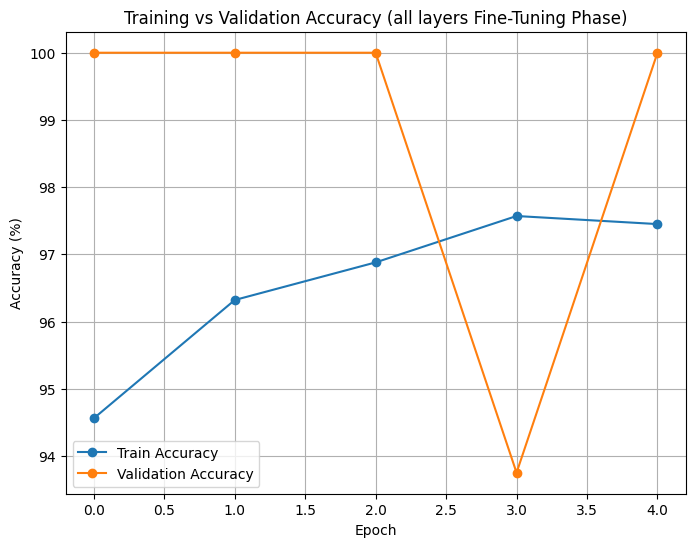

In [12]:
# ============================================================
# Plot: Train Accuracy vs. Validation Accuracy (Fine-Tuning Phase)
# ============================================================
import matplotlib.pyplot as plt

train_accuracies_ft = [94.56, 96.32, 96.88, 97.57, 97.45]
val_accuracies_ft =   [100.00, 100.00, 100.00, 93.75, 100.00]

plt.figure(figsize=(8,6))
plt.plot(train_accuracies_ft, label="Train Accuracy", marker='o')
plt.plot(val_accuracies_ft, label="Validation Accuracy", marker='o')
plt.title("Training vs Validation Accuracy (all layers Fine-Tuning Phase)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


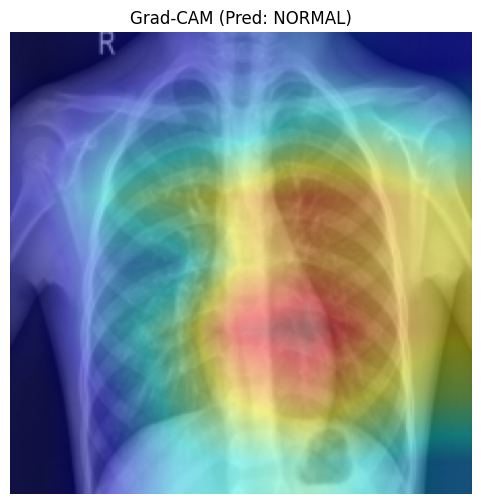

In [13]:
# ============================================================
# Grad-CAM Visualization (Refined)
# ============================================================

def generate_gradcam(model, img_tensor, target_layer):
    model.eval()
    gradients, activations = [], []

    # Define hooks
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    def forward_hook(module, inp, out):
        activations.append(out.detach())

    # Register hooks
    h_f = target_layer.register_forward_hook(forward_hook)
    h_b = target_layer.register_backward_hook(backward_hook)

    # Forward pass
    outputs = model(img_tensor)
    pred_class = outputs.argmax(dim=1)

    # Backward pass
    model.zero_grad()
    outputs[0, pred_class].backward()

    # Extract Grad-CAM data
    grads = gradients[0].cpu().numpy()[0]
    acts = activations[0].cpu().numpy()[0]

    weights = np.mean(grads, axis=(1, 2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * acts[i, :, :]

    cam = np.maximum(cam, 0)
    cam /= cam.max() if cam.max() != 0 else 1

    # Remove hooks
    h_f.remove()
    h_b.remove()

    return cam, pred_class.item()


# ============================================================
# Visualization Example
# ============================================================
sample_img, _ = test_data[0]
input_tensor = sample_img.unsqueeze(0).to(device)

# For ResNet50 last convolution block
target_layer = model.layer4[-1].conv3

cam, pred = generate_gradcam(model, input_tensor, target_layer)

# Unnormalize the image (reverse ImageNet normalization)
img_np = sample_img.cpu().numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_unnorm = np.clip(std * img_np + mean, 0, 1)
img_disp = np.uint8(img_unnorm * 255)

# Create heatmap overlay
cam_resized = cv2.resize(cam, (224, 224))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(heatmap, 0.4, img_disp, 0.6, 0)

plt.figure(figsize=(6, 6))
plt.imshow(overlay[..., ::-1])  # Convert BGR → RGB
plt.title(f"Grad-CAM (Pred: {'PNEUMONIA' if pred == 1 else 'NORMAL'})")
plt.axis('off')
plt.show()


In [14]:
# ============================================================
# Gradio Inference App
# ============================================================
def predict_pneumonia(img):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        label = "PNEUMONIA" if pred == 1 else "NORMAL"
        confidence = probs[0][pred].item()
    return {label: confidence}

interface = gr.Interface(
    fn=predict_pneumonia,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="PneumoNet - ResNet50 Pneumonia Detection",
    description="Upload a chest X-ray image to predict whether it's Pneumonia or Normal."
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bb0b3560d79d83e745.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
!pip install shap lime scikit-image


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ae1b5e50591a840f22be65a2157ba89ac56c4fe79334ae64155ffb0a1c96d1a1
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [36]:
import os
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import copy
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries


In [37]:
# ---- Device Setup ----
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ---- Load the trained model ----
# Make sure 'model' is already defined from your training step
model.eval()
model.to(device)

# ---- Preprocessing ----
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- Load test images ----
test_dir = "/content/drive/MyDrive/chest_xray/test"

test_image_paths = []
for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            test_image_paths.append(os.path.join(root, file))

print(f"Found {len(test_image_paths)} test images.")

# ---- Load and preprocess images ----
test_imgs = torch.stack([
    preprocess(Image.open(p).convert("RGB")) for p in test_image_paths
]).to(device)

# ---- Run predictions ----
with torch.no_grad():
    outputs = model(test_imgs)
    probs = torch.nn.functional.softmax(outputs, dim=1)
    preds = probs.argmax(dim=1)

# ---- Print predictions ----
for i, path in enumerate(test_image_paths):
    print(f"Image: {os.path.basename(path)} | Predicted: {preds[i].item()} | Confidence: {probs[i][preds[i]].item():.4f}")


Using device: cuda
Found 624 test images.
Image: person110_bacteria_531.jpeg | Predicted: 1 | Confidence: 0.9830
Image: person111_bacteria_536.jpeg | Predicted: 1 | Confidence: 0.9996
Image: person130_bacteria_628.jpeg | Predicted: 1 | Confidence: 0.9990
Image: person147_bacteria_711.jpeg | Predicted: 1 | Confidence: 0.9976
Image: person137_bacteria_655.jpeg | Predicted: 1 | Confidence: 0.9983
Image: person124_bacteria_589.jpeg | Predicted: 1 | Confidence: 0.9994
Image: person118_bacteria_559.jpeg | Predicted: 1 | Confidence: 0.9863
Image: person134_bacteria_640.jpeg | Predicted: 1 | Confidence: 0.9075
Image: person117_bacteria_557.jpeg | Predicted: 0 | Confidence: 0.9270
Image: person122_bacteria_582.jpeg | Predicted: 1 | Confidence: 0.9999
Image: person123_bacteria_587.jpeg | Predicted: 1 | Confidence: 0.9981
Image: person100_bacteria_480.jpeg | Predicted: 1 | Confidence: 0.9993
Image: person130_bacteria_627.jpeg | Predicted: 1 | Confidence: 0.9928
Image: person100_bacteria_482.jpeg 

<Figure size 1000x600 with 0 Axes>

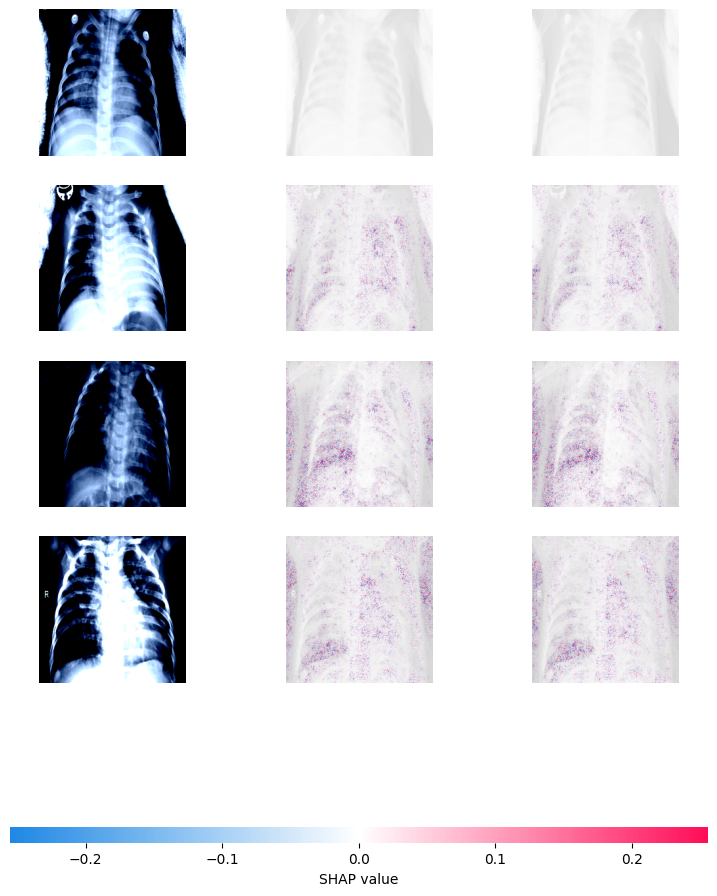

In [44]:
# =========================================================
# ✅ SHAP GradientExplainer for CNN (Clean Working Version)
# =========================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

# ---- Create a model copy for SHAP ----
model_for_shap = copy.deepcopy(model).to(device)
model_for_shap.eval()

# ---- Select sample and background images (already on GPU) ----
sample_imgs = test_imgs[:4]     # shape: (4, 3, 224, 224)
background = test_imgs[:1]      # shape: (1, 3, 224, 224)

# ---- Initialize SHAP GradientExplainer ----
e = shap.GradientExplainer(model_for_shap, background)

# ---- Compute SHAP values ----
shap_values = e.shap_values(sample_imgs)   # shape: (N, C, H, W, num_classes)

# ---- Convert numpy (N, C, H, W, K) -> list of K arrays of shape (N, H, W, C) ----
num_classes = shap_values.shape[-1]
N, C, H, W, K = shap_values.shape

shap_values_list = []
for class_idx in range(K):
    sv = shap_values[..., class_idx]       # (N, C, H, W)
    sv = np.transpose(sv, (0, 2, 3, 1))    # (N, H, W, C)
    shap_values_list.append(sv)

# ---- Convert sample images to numpy (HWC) ----
test_imgs_np = sample_imgs.detach().cpu().permute(0, 2, 3, 1).numpy()

# ---- Plot ----
plt.figure(figsize=(10, 6))
shap.image_plot(shap_values_list, test_imgs_np)
plt.show()



  0%|          | 0/1000 [00:00<?, ?it/s]

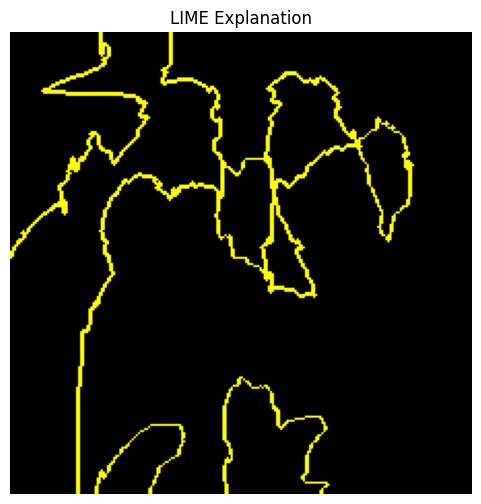

In [33]:
# ==========================
# LIME Explainability for Chest X-Ray Classification
# ==========================
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image

# Define a preprocessing function
def preprocess_image(img_tensor):
    img = img_tensor.squeeze().detach().cpu().numpy()
    if img.shape[0] == 1:  # grayscale
        img = np.repeat(img, 3, axis=0)
    img = np.transpose(img, (1, 2, 0))
    img = (img - img.min()) / (img.max() - img.min())  # normalize 0–1
    return img

# Create LIME explainer
explainer = lime_image.LimeImageExplainer()

# Define prediction function for LIME
def predict_fn(images):
    images = torch.tensor(np.transpose(images, (0, 3, 1, 2)), dtype=torch.float32).to(device)
    outputs = model(images)
    probs = torch.nn.functional.softmax(outputs, dim=1).detach().cpu().numpy()
    return probs

# Run LIME on one test image
test_img = test_imgs[0:1]
test_img_np = preprocess_image(test_img[0])

explanation = explainer.explain_instance(
    test_img_np,
    predict_fn,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

# Get LIME visualization
from skimage.color import label2rgb

temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=False,
    hide_rest=False,
    num_features=10,
    min_weight=0.0
)

plt.figure(figsize=(6, 6))
plt.title("LIME Explanation")
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis('off')
plt.show()
